# Практическое задание - Анализ векторных представлений лемм

В этом проекте выполняется задача по исследованию **адекватности метода кластеризации** векторных представлений лемм с использованием косинусной меры для нахождения ближайших кластеров.

Проект включает следующие этапы:
1. Получение векторных представлений для лемм с использованием модели **deberta-v3-base**.
2. Кластеризация векторных представлений и вычисление центроидов классов.
3. Визуализация результатов с помощью методов **PCA** и **t-SNE**.
4. Анализ ошибок классификации.

In [1]:
import torch
import torch.nn.functional as F
import transformers
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

from collections import Counter, defaultdict
from transformers import AutoTokenizer, AutoModel
from nltk.corpus import semcor
from nltk.corpus.reader.wordnet import Lemma
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)

Torch version: 2.10.0+cpu
Transformers version: 5.3.0


In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModel.from_pretrained(model_name, output_hidden_states=True).to(DEVICE)

model.eval()

BEST_LAYER = 8

print("Model loaded successfully")
print("Device:", DEVICE)
print("Best layer:", BEST_LAYER)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully
Device: cpu
Best layer: 8


In [3]:
nltk.download("semcor")
nltk.download("wordnet")

[nltk_data] Downloading package semcor to
[nltk_data]     C:\Users\zador\AppData\Roaming\nltk_data...
[nltk_data]   Package semcor is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zador\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
import os

os.makedirs("figures", exist_ok=True)
print("Folder 'figures' is ready")

Folder 'figures' is ready


In [5]:
sentences = semcor.sents()
tagged_sents = semcor.tagged_sents(tag='sem')

print("Number of plain sentences:", len(sentences))
print("Number of tagged sentences:", len(tagged_sents))
print("First sentence:")
print(sentences[0])

Number of plain sentences: 37176
Number of tagged sentences: 37176
First sentence:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [6]:
sentence_words = ["Watson", "stumbled", "down", "the", "bank", "."]
bank_word_index = 4

encoding = tokenizer(
    sentence_words,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True
)

word_ids = encoding.word_ids(batch_index=0)

model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**model_inputs)

layer_embeddings = outputs.hidden_states[BEST_LAYER][0].cpu()

token_indices = [i for i, wid in enumerate(word_ids) if wid == bank_word_index]

bank_embedding = layer_embeddings[token_indices].mean(dim=0)

print("Sentence words:", sentence_words)
print("Target word:", sentence_words[bank_word_index])
print("Word ids:", word_ids)
print("Token indices for 'bank':", token_indices)
print("Embedding shape:", bank_embedding.shape)
print(bank_embedding[:10])

Sentence words: ['Watson', 'stumbled', 'down', 'the', 'bank', '.']
Target word: bank
Word ids: [0, 1, 2, 3, 4, 5]
Token indices for 'bank': [4]
Embedding shape: torch.Size([768])
tensor([ 0.2612,  0.7905,  0.3171, -0.0025,  0.0673, -0.8066, -0.9346, -0.5459,
         1.1182, -0.4558], dtype=torch.float16)


## Этап 1: Получение векторных представлений для лемм

Для этого этапа мы использовали модель **deberta-v3-base** для получения векторных представлений лемм, таких как `plant` и `table`. Векторные представления для каждого слова вычисляются с использованием тренированной модели. Эти представления далее используются для кластеризации и визуализации.

In [7]:
def get_word_embedding(sentence_words, target_word_index, layer_idx=BEST_LAYER):
    encoding = tokenizer(
        sentence_words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = encoding.word_ids(batch_index=0)
    model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**model_inputs)

    layer_embeddings = outputs.hidden_states[layer_idx][0].cpu()

    token_indices = [
        i for i, wid in enumerate(word_ids)
        if wid == target_word_index
    ]

    if len(token_indices) == 0:
        return None

    return layer_embeddings[token_indices].mean(dim=0)


In [8]:
emb = get_word_embedding(sentence_words, bank_word_index)

print("Embedding shape from function:", emb.shape if emb is not None else None)
print(emb[:10] if emb is not None else None)

Embedding shape from function: torch.Size([768])
tensor([ 0.2612,  0.7905,  0.3171, -0.0025,  0.0673, -0.8066, -0.9346, -0.5459,
         1.1182, -0.4558], dtype=torch.float16)


## Этап 2: Извлечение примеров для леммы

В этом шаге мы извлекаем примеры предложений для заданной леммы, используя **NLTK** и корпус **SemCor**. Примеры выбираются на основе их появления в контексте леммы и их связности. Это важно для дальнейшего анализа и кластеризации.

In [9]:
from nltk.corpus.reader.wordnet import Lemma

def extract_lemma_occurrences(lemma_target, max_examples=200):
    occurrences = []

    for sent in semcor.tagged_sents(tag='sem'):

        sentence_words = []
        targets_in_sent = []

        for item in sent:

            if hasattr(item, "leaves"):
                leaves = item.leaves()
                start_idx = len(sentence_words)
                sentence_words.extend(leaves)
                end_idx = len(sentence_words) - 1

                if hasattr(item, "label"):
                    label = item.label()

                    if isinstance(label, Lemma):
                        lemma_name = label.name()

                        if lemma_name == lemma_target:
                            targets_in_sent.append({
                                "word": " ".join(leaves),
                                "sense": label.synset(),
                                "target_start": start_idx,
                                "target_end": end_idx
                            })

            else:
                if isinstance(item, str):
                    sentence_words.append(item)
                else:
                    sentence_words.extend(item)

        if len(targets_in_sent) > 0:
            sentence = " ".join(sentence_words)

            for target in targets_in_sent:
                occurrences.append({
                    "word": target["word"],
                    "sense": target["sense"],
                    "sentence": sentence,
                    "sentence_words": sentence_words.copy(),
                    "target_start": target["target_start"],
                    "target_end": target["target_end"]
                })

                if len(occurrences) >= max_examples:
                    return occurrences

    return occurrences

In [10]:
examples = extract_lemma_occurrences("bank", max_examples=20)

print("Number of examples:", len(examples))
print()

for ex in examples[:5]:
    print("WORD:", ex["word"])
    print("SENSE:", ex["sense"])
    print("SENTENCE:", ex["sentence"])
    print()

Number of examples: 20

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: The bill , which Daniel said he drafted personally , would force banks , insurance firms , pipeline companies and other corporations to report such property to the state treasurer .

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote when he said it would force banks to violate their contractual obligations with depositors and undermine the confidence of bank customers .

WORD: bank
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote when he said it would force banks to violate their contractual obligations with depositors and undermine the confidence of bank customers .

WORD: banks
SENSE: Synset('depository_financial_institution.n.01'

In [11]:
all_bank_examples = extract_lemma_occurrences("bank", max_examples=1000)

sense_counts = Counter(ex["sense"] for ex in all_bank_examples)

print("Number of total bank examples:", len(all_bank_examples))
print()

for sense, count in sense_counts.most_common():
    print(sense, "->", count)

Number of total bank examples: 40

Synset('depository_financial_institution.n.01') -> 20
Synset('bank.n.01') -> 14
Synset('bank.n.03') -> 2
Synset('bank.v.01') -> 2
Synset('bank.n.04') -> 1
Synset('bank.v.02') -> 1


In [12]:
def get_word_embedding_from_example(example, layer_idx=BEST_LAYER):
    sentence_words = example["sentence_words"]
    target_start = example["target_start"]
    target_end = example["target_end"]

    encoding = tokenizer(
        sentence_words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = encoding.word_ids(batch_index=0)

    model_inputs = {k: v.to(DEVICE) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**model_inputs)

    layer_embeddings = outputs.hidden_states[layer_idx][0].cpu()

    token_indices = [
        i for i, wid in enumerate(word_ids)
        if wid is not None and target_start <= wid <= target_end
    ]

    if len(token_indices) == 0:
        return None

    word_embedding = layer_embeddings[token_indices].mean(dim=0)
    return word_embedding

In [13]:
top_senses = [sense for sense, count in sense_counts.most_common(2)]

filtered_examples = [
    ex for ex in all_bank_examples
    if ex["sense"] in top_senses
]

test_ex = filtered_examples[0]

print("WORD:", test_ex["word"])
print("SENSE:", test_ex["sense"])
print("SENTENCE:", test_ex["sentence"])

emb = get_word_embedding_from_example(test_ex)

print()
print("Embedding shape:", emb.shape if emb is not None else None)

WORD: banks
SENSE: Synset('depository_financial_institution.n.01')
SENTENCE: The bill , which Daniel said he drafted personally , would force banks , insurance firms , pipeline companies and other corporations to report such property to the state treasurer .

Embedding shape: torch.Size([768])


In [14]:
def cosine_similarity(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

In [15]:
def compute_centroid(embeddings):
    if len(embeddings) == 0:
        raise ValueError("compute_centroid: empty embeddings list")

    return torch.stack(embeddings).mean(dim=0)

## Этап 3: Анализ леммы

После того как мы извлекли примеры для леммы, применяем **кластеризацию** векторных представлений этих примеров. Для каждого класса мы вычисляем **центроиды**, а затем на основе их косинусного сходства предсказываем лемму для тестовых данных.

Этот этап включает разделение данных на обучающие и тестовые, кластеризацию и вычисление ошибок классификации.

In [16]:
def analyze_lemma(lemma, max_examples=1000, min_examples_per_sense=4, keep_top_k_for_analysis=2):
    all_examples = extract_lemma_occurrences(lemma, max_examples=max_examples)

    if len(all_examples) == 0:
        return None

    sense_counts = Counter(ex["sense"] for ex in all_examples)

    if len(sense_counts) < 2:
        return None

    all_senses = list(sense_counts.keys())

    top_senses = [sense for sense, count in sense_counts.most_common(keep_top_k_for_analysis)]

    filtered_examples = [
        ex for ex in all_examples
        if ex["sense"] in top_senses
    ]

    sense_to_examples = defaultdict(list)
    for ex in filtered_examples:
        sense_to_examples[ex["sense"]].append(ex)

    if any(len(v) < min_examples_per_sense for v in sense_to_examples.values()):
        return None

    train_examples = []
    test_examples = []

    for sense, exs in sense_to_examples.items():
        split_idx = int(0.7 * len(exs))

        if split_idx == 0 or split_idx == len(exs):
            return None

        train_examples.extend(exs[:split_idx])
        test_examples.extend(exs[split_idx:])

    train_sense_to_embeddings = defaultdict(list)
    test_sense_to_embeddings = defaultdict(list)

    for ex in train_examples:
        emb = get_word_embedding_from_example(ex)
        if emb is not None:
            train_sense_to_embeddings[ex["sense"]].append(emb)

    for ex in test_examples:
        emb = get_word_embedding_from_example(ex)
        if emb is not None:
            test_sense_to_embeddings[ex["sense"]].append(emb)

    if len(train_sense_to_embeddings) < 2 or len(test_sense_to_embeddings) < 2:
        return None

    train_sense_to_centroid = {}
    for sense, emb_list in train_sense_to_embeddings.items():
        if len(emb_list) == 0:
            return None
        train_sense_to_centroid[sense] = compute_centroid(emb_list)

    def predict_sense_from_embedding(embedding, centroids):
        best_sense = None
        best_score = -1

        for sense, centroid in centroids.items():
            score = cosine_similarity(embedding, centroid)
            if score > best_score:
                best_score = score
                best_sense = sense

        return best_sense, best_score

    test_results = []
    for sense, emb_list in test_sense_to_embeddings.items():
        for emb in emb_list:
            pred_sense, score = predict_sense_from_embedding(emb, train_sense_to_centroid)
            test_results.append({
                "true_sense": sense,
                "pred_sense": pred_sense,
                "score": score,
                "correct": (sense == pred_sense),
                "embedding": emb
            })

    errors = [r for r in test_results if not r["correct"]]

    return {
        "lemma": lemma,
        "all_examples": all_examples,                  
        "sense_counts": sense_counts,                  
        "all_senses": all_senses,                    
        "top_senses": top_senses,                     
        "filtered_examples": filtered_examples,        
        "train_examples": train_examples,
        "test_examples": test_examples,
        "train_sense_to_embeddings": train_sense_to_embeddings,
        "test_sense_to_embeddings": test_sense_to_embeddings,
        "train_sense_to_centroid": train_sense_to_centroid,
        "test_results": test_results,
        "errors": errors
    }

## Этап 4: Визуализация результатов

После кластеризации и предсказания лемм мы используем методы **PCA** и **t-SNE** для снижения размерности и визуализации результатов в 2D. Мы отображаем **точки** для каждого примера и **центроиды** классов.

Ошибочные классификации отображаются как **крестики** с номерами, чтобы можно было анализировать, где произошли ошибки.

In [17]:
def visualize_result(res, method="pca", perplexity=5, save_path=None):
    train_sense_to_embeddings = res["train_sense_to_embeddings"]
    test_results = res["test_results"]
    train_sense_to_centroid = res["train_sense_to_centroid"]

    all_train_embeddings = []
    all_train_labels = []
    for sense, emb_list in train_sense_to_embeddings.items():
        for emb in emb_list:
            all_train_embeddings.append(emb.numpy())
            all_train_labels.append(str(sense))

    all_train_embeddings = np.array(all_train_embeddings)

    all_test_embeddings = np.array([r["embedding"].numpy() for r in test_results])
    all_test_labels = [str(r["true_sense"]) for r in test_results]

    all_centroids = np.array([centroid.numpy() for centroid in train_sense_to_centroid.values()])
    centroid_labels = [str(sense) for sense in train_sense_to_centroid.keys()]

    X_all = np.vstack([all_train_embeddings, all_test_embeddings, all_centroids])

    n_train = len(all_train_embeddings)
    n_test = len(all_test_embeddings)

    if method == "pca":
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_all)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        X_2d = reducer.fit_transform(X_all)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    train_2d = X_2d[:n_train]
    test_2d = X_2d[n_train:n_train+n_test]
    cent_2d = X_2d[n_train+n_test:]

    unique_labels = sorted(set(all_train_labels))
    colors = ["blue", "green", "red", "orange", "purple", "brown"]
    label_to_color = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

    plt.figure(figsize=(10, 7))

    # train points
    for label in unique_labels:
        idxs = [i for i, l in enumerate(all_train_labels) if l == label]
        plt.scatter(
            train_2d[idxs, 0],
            train_2d[idxs, 1],
            c=label_to_color[label],
            label=f"train: {label}",
            alpha=0.7
        )

    # test points
    for i, label in enumerate(all_test_labels):
        marker = "x" if not test_results[i]["correct"] else "o"
        plt.scatter(
            test_2d[i, 0],
            test_2d[i, 1],
            c=label_to_color[label],
            marker=marker,
            s=100,
            edgecolors="black" if marker == "o" else None
        )
        
    # centroids
    centroid_labels = list(train_sense_to_centroid.keys())

    for i, sense in enumerate(centroid_labels):
        label = str(sense)

        plt.scatter(
            cent_2d[i, 0],
            cent_2d[i, 1],
            c=label_to_color[label],
            marker="X",
            s=300,
            edgecolors="black"
        )

    plt.title(f"{method.upper()} visualization of lemma '{res['lemma']}'")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [18]:
candidate_lemmas = ["bank", "plant", "yard", "table", "arm", "paper", "board", "land", "head", "line"]

results_summary = []

for lemma in candidate_lemmas:
    res = analyze_lemma(lemma, max_examples=1000)
    if res is not None:
        results_summary.append((lemma, len(res["errors"]), res["sense_counts"]))
        print(f"{lemma}: errors = {len(res['errors'])}")
        print(res["sense_counts"])
        print()

bank: errors = 1
Counter({Synset('depository_financial_institution.n.01'): 20, Synset('bank.n.01'): 14, Synset('bank.n.03'): 2, Synset('bank.v.01'): 2, Synset('bank.n.04'): 1, Synset('bank.v.02'): 1})

plant: errors = 9
Counter({Synset('plant.n.01'): 63, Synset('plant.n.02'): 36, Synset('plant.v.01'): 8, Synset('implant.v.01'): 2, Synset('establish.v.02'): 1})

yard: errors = 5
Counter({Synset('yard.n.01'): 34, Synset('yard.n.02'): 12, Synset('yard.n.03'): 1})

table: errors = 4
Counter({Synset('table.n.01'): 52, Synset('table.n.02'): 25, Synset('table.n.03'): 4})

arm: errors = 1
Counter({Synset('arm.n.01'): 68, Synset('arm.v.01'): 4, Synset('arm.n.02'): 1, Synset('arm.n.04'): 1, Synset('weapon.n.01'): 1, Synset('arm.v.02'): 1})

paper: errors = 3
Counter({Synset('paper.n.01'): 29, Synset('composition.n.08'): 21, Synset('newspaper.n.01'): 12, Synset('paper.n.04'): 4, Synset('paper.n.05'): 3, Synset('newspaper.n.02'): 2})

board: errors = 2
Counter({Synset('board.n.01'): 28, Synset('bo

In [19]:
plant_res = analyze_lemma("plant", max_examples=1000)
table_res = analyze_lemma("table", max_examples=1000)

print("plant errors:", len(plant_res["errors"]) if plant_res is not None else None)
print("table errors:", len(table_res["errors"]) if table_res is not None else None)

plant errors: 9
table errors: 4


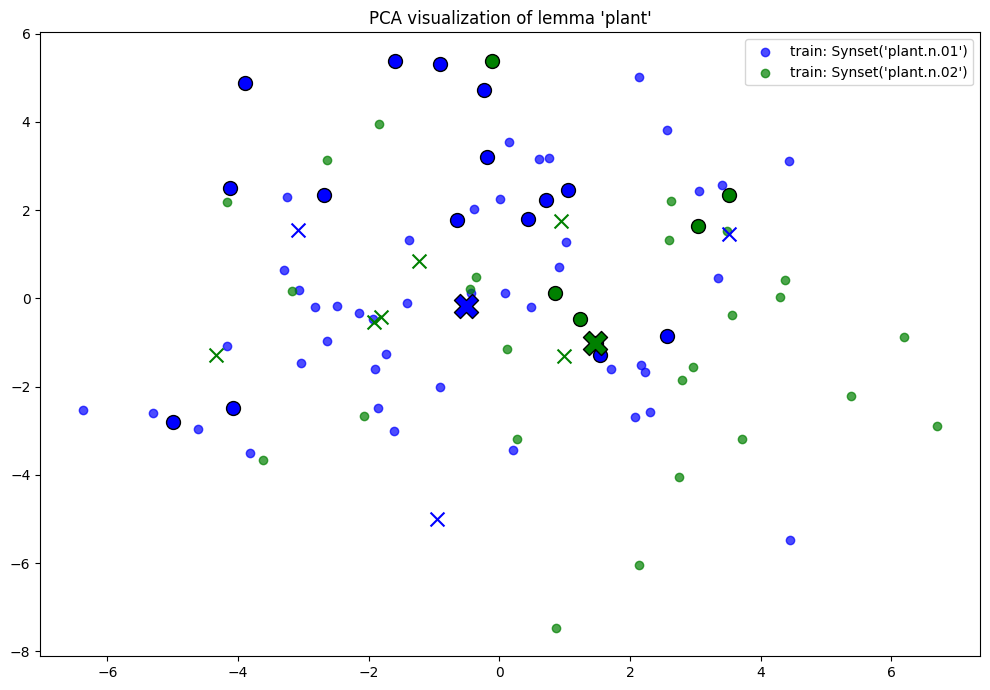

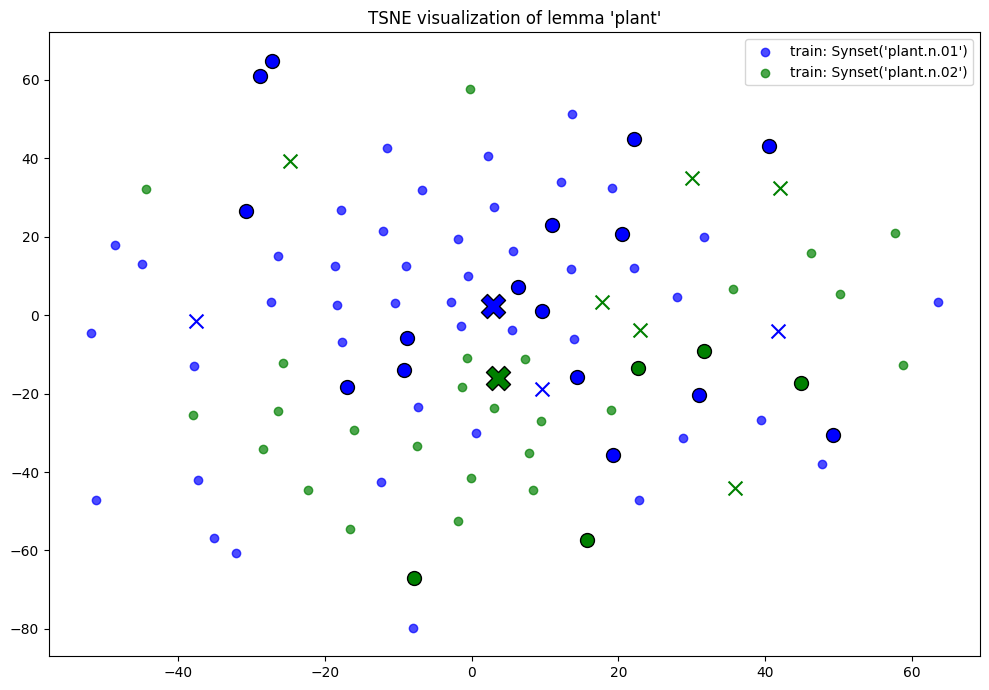

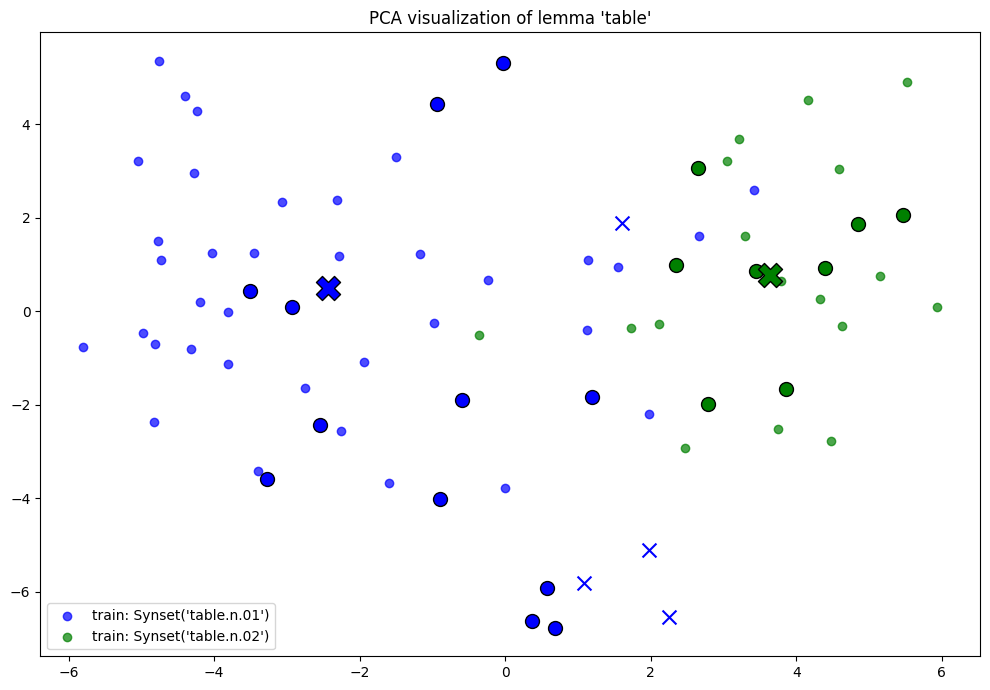

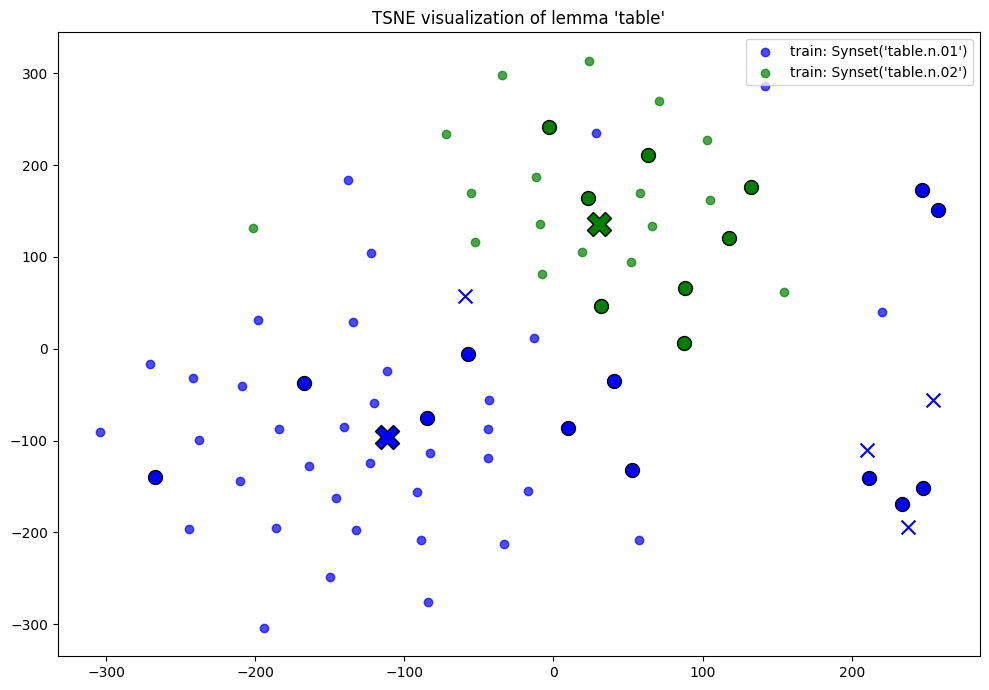

In [20]:
visualize_result(plant_res, method="pca",  save_path="figures/plant_pca.png")
visualize_result(plant_res, method="tsne", save_path="figures/plant_tsne.png")

visualize_result(table_res, method="pca",  save_path="figures/table_pca.png")
visualize_result(table_res, method="tsne", save_path="figures/table_tsne.png")

In [21]:
print("Ошибки для plant:")
for i, err in enumerate(plant_res["errors"]):
    print(f"\nОшибка {i}")
    print("TRUE:", err["true_sense"])
    print("PRED:", err["pred_sense"])
    print("SCORE:", err["score"])

Ошибки для plant:

Ошибка 0
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.796875

Ошибка 1
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.70263671875

Ошибка 2
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.7333984375

Ошибка 3
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.76318359375

Ошибка 4
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.6875

Ошибка 5
TRUE: Synset('plant.n.02')
PRED: Synset('plant.n.01')
SCORE: 0.78857421875

Ошибка 6
TRUE: Synset('plant.n.01')
PRED: Synset('plant.n.02')
SCORE: 0.78662109375

Ошибка 7
TRUE: Synset('plant.n.01')
PRED: Synset('plant.n.02')
SCORE: 0.70947265625

Ошибка 8
TRUE: Synset('plant.n.01')
PRED: Synset('plant.n.02')
SCORE: 0.81103515625


In [22]:
print("Ошибки для table:")
for i, err in enumerate(table_res["errors"]):
    print(f"\nОшибка {i}")
    print("TRUE:", err["true_sense"])
    print("PRED:", err["pred_sense"])
    print("SCORE:", err["score"])

Ошибки для table:

Ошибка 0
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.64697265625

Ошибка 1
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.76904296875

Ошибка 2
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.65771484375

Ошибка 3
TRUE: Synset('table.n.01')
PRED: Synset('table.n.02')
SCORE: 0.693359375


## Этап 5: Визуализация результатов с ID ошибок

В этом шаге мы используем улучшенную версию визуализации с ID ошибок. Ошибки классификации отображаются как **крестики** с номерами, чтобы точно указать, какие точки были классифицированы неправильно.

Мы визуализируем данные с использованием **PCA** и **t-SNE**, а также добавляем информацию о классификационных ошибках.

In [23]:
def visualize_result_with_error_ids(res, method="pca", perplexity=5, save_path=None):
    train_sense_to_embeddings = res["train_sense_to_embeddings"]
    test_results = res["test_results"]
    train_sense_to_centroid = res["train_sense_to_centroid"]

    all_train_embeddings = []
    all_train_labels = []
    for sense, emb_list in train_sense_to_embeddings.items():
        for emb in emb_list:
            all_train_embeddings.append(emb.numpy())
            all_train_labels.append(str(sense))

    all_train_embeddings = np.array(all_train_embeddings)

    all_test_embeddings = np.array([r["embedding"].numpy() for r in test_results])
    all_test_labels = [str(r["true_sense"]) for r in test_results]

    all_centroids = np.array([centroid.numpy() for centroid in train_sense_to_centroid.values()])
    centroid_labels = [str(sense) for s, centroid in train_sense_to_centroid.items()]

    X_all = np.vstack([all_train_embeddings, all_test_embeddings, all_centroids])

    n_train = len(all_train_embeddings)
    n_test = len(all_test_embeddings)

    if method == "pca":
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_all)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        X_2d = reducer.fit_transform(X_all)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    train_2d = X_2d[:n_train]
    test_2d = X_2d[n_train:n_train+n_test]
    cent_2d = X_2d[n_train+n_test:]

    unique_labels = sorted(set(all_train_labels))
    colors = ["blue", "green", "red", "orange", "purple", "brown"]
    label_to_color = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

    plt.figure(figsize=(10, 7))

    # train points
    for label in unique_labels:
        idxs = [i for i, l in enumerate(all_train_labels) if l == label]
        plt.scatter(
            train_2d[idxs, 0],
            train_2d[idxs, 1],
            c=label_to_color[label],
            label=f"train: {label}",
            alpha=0.7
        )

    # test points
    error_count = 0
    for i, label in enumerate(all_test_labels):
        marker = "x" if not test_results[i]["correct"] else "o"
        plt.scatter(
            test_2d[i, 0],
            test_2d[i, 1],
            c=label_to_color[label],
            marker=marker,
            s=100,
            edgecolors="black" if marker == "o" else None
        )

        if not test_results[i]["correct"]:
            plt.text(test_2d[i, 0] + 0.2, test_2d[i, 1] + 0.2, f"Ошибка {error_count}", fontsize=10)
            error_count += 1  
            
    # centroids
    centroid_labels = list(train_sense_to_centroid.keys())

    for i, sense in enumerate(centroid_labels):
        label = str(sense)

        plt.scatter(
            cent_2d[i, 0],
            cent_2d[i, 1],
            c=label_to_color[label],
            marker="X",
            s=300,
            edgecolors="black"
        )

    plt.title(f"{method.upper()} visualization of lemma '{res['lemma']}' with error ids")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

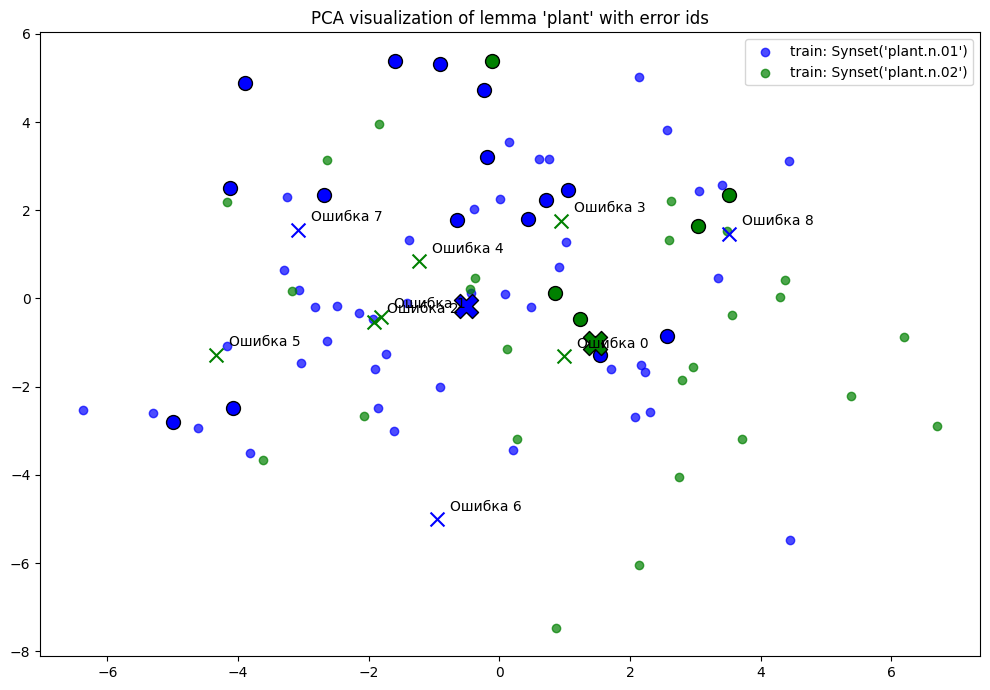

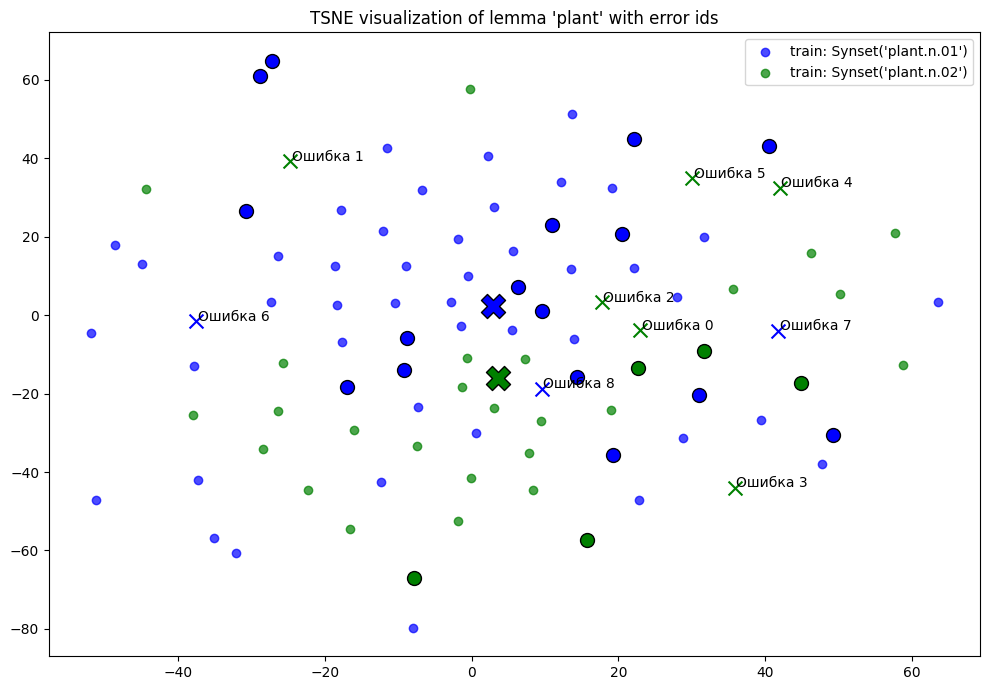

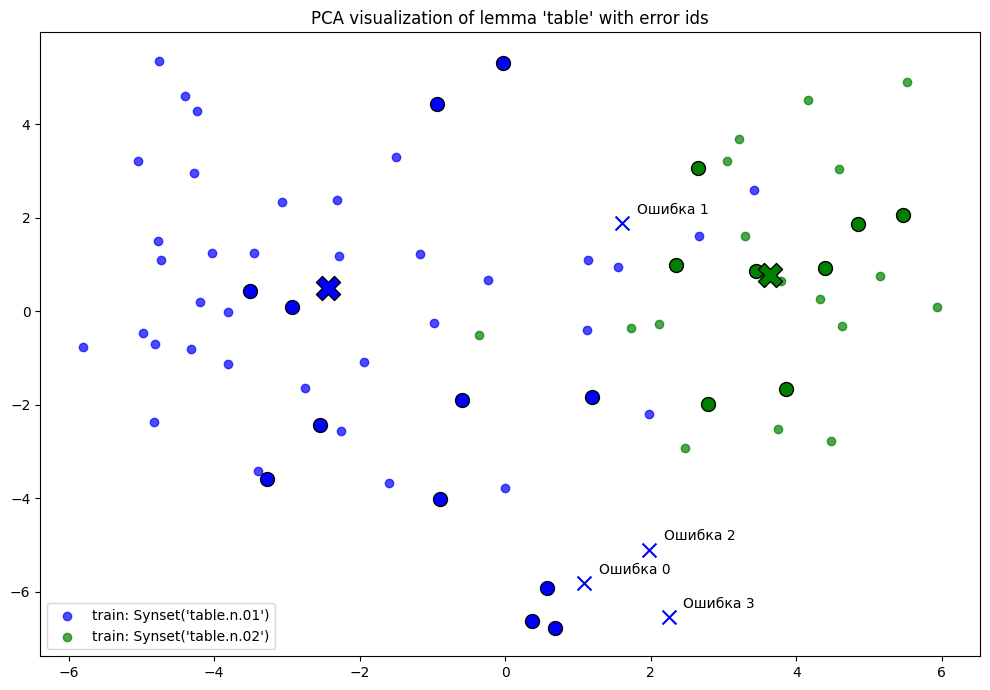

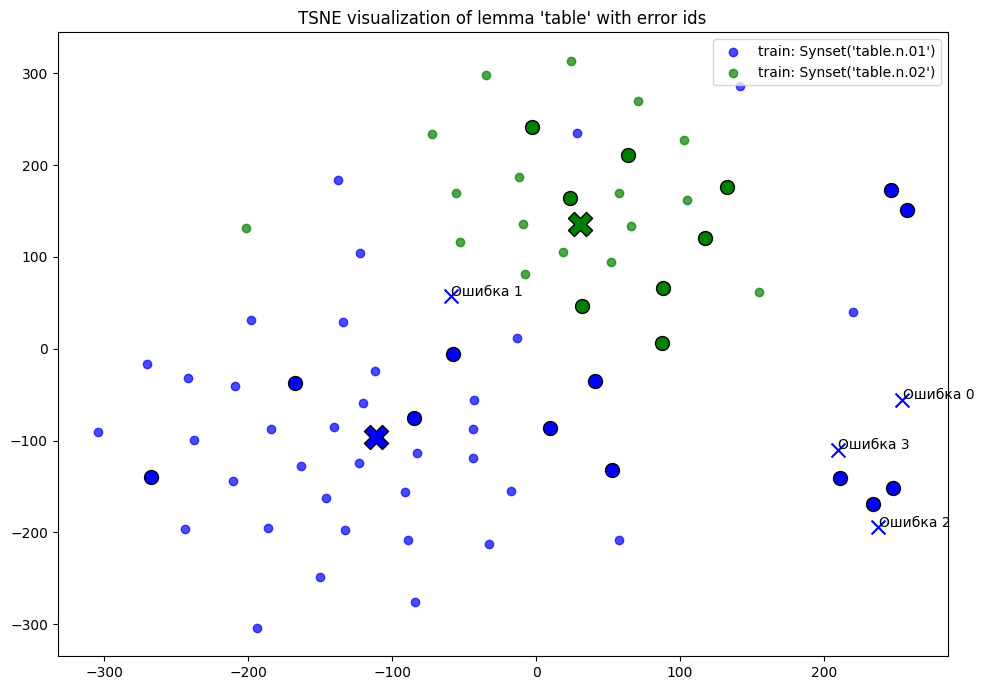

In [24]:
visualize_result_with_error_ids(plant_res, method="pca",  save_path="figures/plant_pca_errors.png")
visualize_result_with_error_ids(plant_res, method="tsne", save_path="figures/plant_tsne_errors.png")

visualize_result_with_error_ids(table_res, method="pca",  save_path="figures/table_pca_errors.png")
visualize_result_with_error_ids(table_res, method="tsne", save_path="figures/table_tsne_errors.png")


## Выводы по ошибкам для plant и table

#### Ошибка 0: `plant.n.02`
- **Истинное значение**: `plant.n.02`
- **Предсказанное значение**: `plant.n.01`
- **Почему произошла ошибка**: точка для `plant.n.02` лежала в правильном кластере для этого значения. Однако предсказание ошиблось и выбрало `plant.n.01` из-за того, что центроиды для этих двух значений (`plant.n.02` и `plant.n.01`) оказались слишком близки друг к другу, что привело к ошибке при классификации.

#### Ошибка 7: `plant.n.01`
- **Истинное значение**: `plant.n.01`
- **Предсказанное значение**: `plant.n.02`
- **Почему произошла ошибка**: точка для `plant.n.01` визуально лежала в кластере для этого значения. Однако метод классификации, основанный на центроидах, ошибся и выбрал `plant.n.02` из-за схожего положения центроидов для этих двух значений.

#### Ошибка 0: `table.n.01`
- **Истинное значение**: `table.n.01`
- **Предсказанное значение**: `table.n.02`
- **Почему произошла ошибка**: точка для `table.n.01` лежала в правильном кластере для этого значения. Однако предсказание ошиблось и выбрало `table.n.01` из-за того, что центроиды для этих двух значений (`plant.n.02` и `plant.n.01`) оказались слишком близки друг к другу, что привело к ошибке при классификации.